# Assignment 3 — Part 1: Data Integration & Quality Assessment

**Project region:** South America  
**Countries:** Argentina, Chile, Peru, Ecuador, Uruguay

This notebook prepares the five COVID-19 datasets for later analysis by loading, inspecting, standardizing, validating, and safely integrating them.

The key rule in this Part 1 pipeline is:

> **Only merge datasets after they share the same granularity.**

This prevents row multiplication and incorrect totals when working with variant and manufacturer datasets.

## 1. Import Libraries and Set Region

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

# Selected South American countries
COUNTRIES = ["Argentina", "Chile", "Peru", "Ecuador", "Uruguay"]

# Change this if your data is inside another folder, e.g. Path("data")
DATA_DIR = Path(".")

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

## 2. Load the Datasets

The notebook expects the five assignment CSV files to be in the same folder as the notebook or inside a nearby `data/` folder.

Expected files:

- `Comprehensive Global COVID-19 Dataset.csv`
- `Vaccinations_ByCountry.csv`
- `Vaccinations_ByCountry_ByManufacturer.csv`
- `Covid19-TestingRecord.csv`
- `Covid19-VariantsFound.csv`

In [2]:
EXPECTED_FILES = {
    "covid": "Comprehensive Global COVID-19 Dataset.csv",
    "vaccination": "Vaccinations_ByCountry.csv",
    "manufacturer": "Vaccinations_ByCountry_ByManufacturer.csv",
    "testing": "Covid19-TestingRecord.csv",
    "variants": "Covid19-VariantsFound.csv"
}

def find_file(filename, search_roots=(Path("."), Path("data"))):
    """Find a file in common project folders. Raises a clear error if missing."""
    for root in search_roots:
        candidate = root / filename
        if candidate.exists():
            return candidate

    # Fallback: recursive search in current working directory
    matches = list(Path(".").rglob(filename))
    if matches:
        return matches[0]

    raise FileNotFoundError(
        f"Could not find {filename}. Put the file in the notebook folder or a data/ folder."
    )

file_paths = {name: find_file(filename) for name, filename in EXPECTED_FILES.items()}
file_paths

{'covid': PosixPath('Comprehensive Global COVID-19 Dataset.csv'),
 'vaccination': PosixPath('Vaccinations_ByCountry.csv'),
 'manufacturer': PosixPath('Vaccinations_ByCountry_ByManufacturer.csv'),
 'testing': PosixPath('Covid19-TestingRecord.csv'),
 'variants': PosixPath('Covid19-VariantsFound.csv')}

In [3]:
covid = pd.read_csv(file_paths["covid"], encoding="latin1")
vaccination = pd.read_csv(file_paths["vaccination"], encoding="latin1")
manufacturer = pd.read_csv(file_paths["manufacturer"], encoding="latin1")
testing = pd.read_csv(file_paths["testing"], encoding="latin1")
variants = pd.read_csv(file_paths["variants"], encoding="latin1")

print("All files loaded successfully.")

All files loaded successfully.


## 3. Inspect Dataset Structure

We inspect row counts, column counts, column names, and sample rows.  
This gives a basic understanding of the structure before cleaning.

In [4]:
datasets = {
    "covid": covid,
    "vaccination": vaccination,
    "manufacturer": manufacturer,
    "testing": testing,
    "variants": variants
}

dataset_summary = pd.DataFrame([
    {
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "column_names": list(df.columns)
    }
    for name, df in datasets.items()
])

dataset_summary

,dataset,rows,columns,column_names
0,covid,238,5,"[S. No., Country Name, Cases, Deaths, Recovered]"
1,vaccination,86512,15,"[country, iso_code, date, total_vaccinations, ..."
2,manufacturer,35623,4,"[location, date, vaccine, total_vaccinations]"
3,testing,74048,14,"[Entity, ISO code, Date, Source URL, Source la..."
4,variants,100416,6,"[location, date, variant, num_sequences, perc_..."


### Raw Dataset Structure Summary

This summary records raw dataset sizes, country/entity counts, and date ranges before regional analysis.

In [5]:
raw_structure_summary = []

for name, df in datasets.items():
    row = {
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1]
    }

    # Country/entity coverage
    if "country" in df.columns:
        row["unique_countries"] = df["country"].nunique()
    elif "Country Name" in df.columns:
        row["unique_countries"] = df["Country Name"].nunique()
    elif "location" in df.columns:
        row["unique_countries"] = df["location"].nunique()
    elif "Entity" in df.columns:
        row["unique_entities"] = df["Entity"].nunique()

    # Date range. Convert temporarily so the summary is reliable.
    if "date" in df.columns:
        temp_date = pd.to_datetime(df["date"], errors="coerce")
        row["start_date"] = temp_date.min()
        row["end_date"] = temp_date.max()
    elif "Date" in df.columns:
        temp_date = pd.to_datetime(df["Date"], errors="coerce")
        row["start_date"] = temp_date.min()
        row["end_date"] = temp_date.max()
    else:
        row["start_date"] = "No date column"
        row["end_date"] = "No date column"

    raw_structure_summary.append(row)

raw_structure_summary = pd.DataFrame(raw_structure_summary)
raw_structure_summary

,dataset,rows,columns,unique_countries,start_date,end_date,unique_entities
0,covid,238,5,230.0,No date column,No date column,NaN
1,vaccination,86512,15,223.0,2020-12-02 00:00:00,2022-03-29 00:00:00,NaN
2,manufacturer,35623,4,43.0,2020-12-04 00:00:00,2022-03-30 00:00:00,NaN
3,testing,74048,14,NaN,2020-01-01 00:00:00,2021-12-10 00:00:00,142.0
4,variants,100416,6,121.0,2020-05-11 00:00:00,2022-01-05 00:00:00,NaN


For the raw testing file, `Entity` combines country and testing method, so the raw summary reports unique entities. Country-level testing coverage is finalized after parsing `Entity` into `country` and `testing_method`.

The comprehensive COVID file contains 238 rows, but only 230 valid country names because 8 rows are blank. These rows are not part of the selected region and are excluded during country filtering.

In [6]:
for name, df in datasets.items():
    print(f"\n{name.upper()} — first 3 rows")
    display(df.head(3))
    print(f"{name.upper()} — data types")
    display(df.dtypes)


COVID — first 3 rows


,S. No.,Country Name,Cases,Deaths,Recovered
0,1.0,Peru,4524748.0,220831.0,4303917.0
1,2.0,Bulgaria,1329266.0,38700.0,1290566.0
2,3.0,Bosnia and Herzegovina,403638.0,16388.0,387250.0


COVID — data types


S. No.          float64
Country Name     object
Cases           float64
Deaths          float64
Recovered       float64
dtype: object


VACCINATION — first 3 rows


...

Entity                                            object
ISO code                                          object
Date                                              object
Source URL                                        object
Source label                                      object
Notes                                             object
Daily change in cumulative total                 float64
Cumulative total                                 float64
Cumulative total per thousand                    float64
Daily change in cumulative total per thousand    float64
7-day smoothed daily change                      float64
7-day smoothed daily change per thousand         float64
Short-term positive rate                         float64
Short-term tests per case                        float64
dtype: object


VARIANTS — first 3 rows


,location,date,variant,num_sequences,perc_sequences,num_sequences_total
0,Angola,2020-07-06,Alpha,0,0.0,3
1,Angola,2020-07-06,B.1.1.277,0,0.0,3
2,Angola,2020-07-06,B.1.1.302,0,0.0,3


VARIANTS — data types


location                object
date                    object
variant                 object
num_sequences            int64
perc_sequences         float64
num_sequences_total      int64
dtype: object

## 4. Standardize Country and Date Columns

The datasets use different names for country and date fields.  
We standardize them so all datasets can be filtered and compared consistently.

The testing dataset requires an extra step because its `Entity` column combines country and testing method, such as:

`Argentina - tests performed`

We split this into:

- `country`
- `testing_method`

In [7]:
# Standardize country column names
covid = covid.rename(columns={"Country Name": "country"})
manufacturer = manufacturer.rename(columns={"location": "country"})
variants = variants.rename(columns={"location": "country"})

# Standardize testing columns
testing = testing.rename(columns={
    "Date": "date",
    "ISO code": "iso_code"
})

# Testing dataset stores country and testing method together in Entity.
# Splitting only on " - " keeps country names like "Trinidad and Tobago" intact.
testing["country"] = testing["Entity"].str.split(" - ", regex=False).str[0]
testing["testing_method"] = testing["Entity"].str.split(" - ", regex=False).str[1]

# Remove accidental leading/trailing spaces in country names
for df in [covid, vaccination, manufacturer, testing, variants]:
    if "country" in df.columns:
        df["country"] = df["country"].astype(str).str.strip()

# Convert date columns
vaccination["date"] = pd.to_datetime(vaccination["date"], errors="coerce")
manufacturer["date"] = pd.to_datetime(manufacturer["date"], errors="coerce")
testing["date"] = pd.to_datetime(testing["date"], errors="coerce")
variants["date"] = pd.to_datetime(variants["date"], errors="coerce")

### Date Conversion Validation

Because we use `errors="coerce"` during date conversion, invalid dates would become missing values.  
This check fails early if any date conversion problems occur.

In [8]:
date_tables = {
    "vaccination": vaccination,
    "manufacturer": manufacturer,
    "testing": testing,
    "variants": variants
}

for name, df in date_tables.items():
    bad_dates = df["date"].isna().sum()
    print(f"{name}: invalid dates = {bad_dates}")
    assert bad_dates == 0, f"{name} contains invalid date values after conversion."

vaccination: invalid dates = 0
manufacturer: invalid dates = 0
testing: invalid dates = 0
variants: invalid dates = 0


## 5. Filter Selected Countries

We now filter the five selected South American countries from each dataset.

In [9]:
covid_region = covid[covid["country"].isin(COUNTRIES)].copy()
vaccination_region = vaccination[vaccination["country"].isin(COUNTRIES)].copy()
manufacturer_region = manufacturer[manufacturer["country"].isin(COUNTRIES)].copy()
testing_region = testing[testing["country"].isin(COUNTRIES)].copy()
variants_region = variants[variants["country"].isin(COUNTRIES)].copy()

region_datasets = {
    "covid_region": covid_region,
    "vaccination_region": vaccination_region,
    "manufacturer_region": manufacturer_region,
    "testing_region": testing_region,
    "variants_region": variants_region
}

coverage = []

for name, df in region_datasets.items():
    coverage.append({
        "dataset": name,
        "rows_after_filtering": df.shape[0],
        "countries_found": sorted(df["country"].dropna().unique())
    })

coverage_df = pd.DataFrame(coverage)
coverage_df

,dataset,rows_after_filtering,countries_found
0,covid_region,5,"[Argentina, Chile, Ecuador, Peru, Uruguay]"
1,vaccination_region,2149,"[Argentina, Chile, Ecuador, Peru, Uruguay]"
2,manufacturer_region,7728,"[Argentina, Chile, Ecuador, Peru, Uruguay]"
3,testing_region,3260,"[Argentina, Chile, Ecuador, Peru, Uruguay]"
4,variants_region,4800,"[Argentina, Chile, Ecuador, Peru, Uruguay]"


## 6. Data Model Decision

The five datasets do **not** have the same granularity.

- **Comprehensive COVID dataset:** one cumulative snapshot row per country.
- **Vaccination dataset:** one row per country and date.
- **Testing dataset:** one row per country and date.
- **Variant dataset:** one row per country, date, and variant.
- **Manufacturer dataset:** one row per country, date, and vaccine manufacturer.

Because of this, we do **not** merge all raw datasets directly. Directly merging variant or manufacturer data into vaccination/testing data would duplicate rows and produce incorrect totals.

Instead:

- variant data is summarized to one row per `country + date` before merging,
- manufacturer data is summarized to one row per `country + date` before merging,
- the comprehensive outcome dataset is kept as a static country-level reference layer.

This preserves the meaning of each dataset.

## 7. Duplicate / Primary Key Checks

Each dataset has a natural level of detail.  
We check duplicates at that expected level before doing any integration.

In [10]:
duplicate_checks = {
    "vaccination_country_date_duplicates": vaccination_region.duplicated(["country", "date"]).sum(),
    "testing_country_date_duplicates": testing_region.duplicated(["country", "date"]).sum(),
    "variants_country_date_variant_duplicates": variants_region.duplicated(["country", "date", "variant"]).sum(),
    "manufacturer_country_date_vaccine_duplicates": manufacturer_region.duplicated(["country", "date", "vaccine"]).sum()
}

duplicate_checks

{'vaccination_country_date_duplicates': np.int64(0),
 'testing_country_date_duplicates': np.int64(0),
 'variants_country_date_variant_duplicates': np.int64(0),
 'manufacturer_country_date_vaccine_duplicates': np.int64(0)}

The duplicate check confirms whether each dataset is unique at its expected level of detail.  
This prevents silent row multiplication during later merges.

## 8. Country-Level Coverage Table

Dataset-level coverage can hide country-specific gaps.  
This table shows the number of rows, number of dates, and date range for each selected country in each time-series dataset.

In [11]:
coverage_rows = []

for country in COUNTRIES:
    row = {"country": country}

    for dataset_name, df in {
        "vaccination": vaccination_region,
        "testing": testing_region,
        "variants": variants_region,
        "manufacturer": manufacturer_region
    }.items():
        country_df = df[df["country"] == country]

        row[f"{dataset_name}_rows"] = len(country_df)
        row[f"{dataset_name}_dates"] = country_df["date"].nunique()
        row[f"{dataset_name}_start"] = country_df["date"].min()
        row[f"{dataset_name}_end"] = country_df["date"].max()

    coverage_rows.append(row)

country_level_coverage = pd.DataFrame(coverage_rows)
country_level_coverage

,country,vaccination_rows,vaccination_dates,vaccination_start,vaccination_end,testing_rows,testing_dates,testing_start,testing_end,variants_rows,variants_dates,variants_start,variants_end,manufacturer_rows,manufacturer_dates,manufacturer_start,manufacturer_end
0,Argentina,456,456,2020-12-29,2022-03-29,704,704,2020-01-01,2021-12-04,1056,44,2020-05-11,2021-12-27,2629,456,2020-12-29,2022-03-29
1,Chile,454,454,2020-12-24,2022-03-22,625,625,2020-03-25,2021-12-09,1056,44,2020-05-11,2021-12-27,1493,454,2020-12-24,2022-03-22
2,Peru,412,412,2021-02-08,2022-03-26,673,673,2020-01-01,2021-11-03,1056,44,2020-05-11,2021-12-27,1140,412,2021-02-08,2022-03-26
3,Ecuador,431,431,2021-01-20,2022-03-26,630,630,2020-03-18,2021-12-07,1056,44,2020-05-11,2021-12-27,1278,374,2021-01-20,2022-01-28
4,Uruguay,396,396,2021-02-27,2022-03-29,628,628,2020-03-22,2021-12-09,576,24,2020-05-11,2021-05-03,1188,396,2021-02-27,2022-03-29


This country-level coverage table shows that coverage is not equal across all selected countries.  
In particular, variant data may have fewer observation dates than vaccination or testing because variant records come from genomic sequencing snapshots rather than daily reporting.

## 9. Missing Values Before Integration

We check missing values before integration so that we do not accidentally hide reporting gaps.

In [12]:
missing_summary = []

for name, df in region_datasets.items():
    total_missing = df.isna().sum().sum()
    total_cells = df.shape[0] * df.shape[1]
    missing_percent = (total_missing / total_cells) * 100 if total_cells > 0 else 0

    missing_summary.append({
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "total_missing_values": total_missing,
        "missing_percent": round(missing_percent, 2)
    })

missing_summary_df = pd.DataFrame(missing_summary)
missing_summary_df

,dataset,rows,columns,total_missing_values,missing_percent
0,covid_region,5,5,0,0.00
1,vaccination_region,2149,15,222,0.69
2,manufacturer_region,7728,4,0,0.00
3,testing_region,3260,16,3622,6.94
4,variants_region,4800,6,0,0.00


In [13]:
for name, df in region_datasets.items():
    print(f"\n{name.upper()} missing values by column:")
    display(df.isna().sum().sort_values(ascending=False).head(10))


COVID_REGION missing values by column:


S. No.       0
country      0
Cases        0
Deaths       0
Recovered    0
dtype: int64


VACCINATION_REGION missing values by column:


people_fully_vaccinated                75
people_fully_vaccinated_per_hundred    75
daily_vaccinations_raw                 18
total_vaccinations                     11
people_vaccinated_per_hundred          11
total_vaccinations_per_hundred         11
people_vaccinated                      11
daily_vaccinations_per_million          5
daily_vaccinations                      5
date                                    0
dtype: int64


MANUFACTURER_REGION missing values by column:


country               0
date                  0
vaccine               0
total_vaccinations    0
dtype: int64


TESTING_REGION missing values by column:


Notes                                            2632
Short-term tests per case                         253
Short-term positive rate                          245
Daily change in cumulative total                   81
Daily change in cumulative total per thousand      81
Cumulative total                                   65
Source URL                                         65
Source label                                       65
Cumulative total per thousand                      65
7-day smoothed daily change per thousand           35
dtype: int64


VARIANTS_REGION missing values by column:


country                0
date                   0
variant                0
num_sequences          0
perc_sequences         0
num_sequences_total    0
dtype: int64

## 10. Testing Method Check

Testing data is not perfectly comparable because countries may use different counting definitions.

In [14]:
testing_methods = (
    testing_region
    .groupby("country")["testing_method"]
    .unique()
    .reset_index()
)

testing_methods

,country,testing_method
0,Argentina,[tests performed]
1,Chile,[tests performed]
2,Ecuador,[people tested]
3,Peru,[tests performed]
4,Uruguay,[people tested]


The parsing step should successfully separate country and testing method for all selected testing records.

In [15]:
assert testing_region["testing_method"].notna().all(), "Some testing methods were not parsed correctly."
print("Testing method parsing validation passed.")

Testing method parsing validation passed.


Testing definitions differ across countries, so testing metrics are interpreted as **visibility indicators** rather than perfectly equivalent testing volume.

## 11. Create Variant Daily Summary

The raw variant dataset has multiple rows per country-date because each variant has its own row.

To safely merge variant information into a country-date table, we create a summary with one row per country-date.  
The dominant variant is the variant with the highest percentage on that sequencing date.

Dominant variant is selected only for dates with sequencing observations. If variants have very close percentages or ties, the selected row should not be interpreted as exact epidemiological dominance.

In [16]:
# Keep only rows with valid sequencing observations.
variants_observed = variants_region[
    variants_region["date"].notna() &
    variants_region["perc_sequences"].notna() &
    variants_region["num_sequences_total"].notna() &
    (variants_region["num_sequences_total"] > 0)
].copy()

# Flag ties where more than one variant shares the maximum percentage on the same country-date.
variant_max = (
    variants_observed
    .groupby(["country", "date"])["perc_sequences"]
    .transform("max")
)

variant_tie_flags = (
    variants_observed[variants_observed["perc_sequences"] == variant_max]
    .groupby(["country", "date"])
    .size()
    .reset_index(name="variant_tie_count")
)

variant_daily_summary = (
    variants_observed
    .sort_values(
        ["country", "date", "perc_sequences"],
        ascending=[True, True, False]
    )
    .groupby(["country", "date"])
    .first()
    .reset_index()
    [["country", "date", "variant", "perc_sequences", "num_sequences_total"]]
    .rename(columns={
        "variant": "dominant_variant",
        "perc_sequences": "dominant_variant_percent"
    })
)

variant_daily_summary = variant_daily_summary.merge(
    variant_tie_flags,
    on=["country", "date"],
    how="left"
)

variant_daily_summary["has_variant_tie"] = variant_daily_summary["variant_tie_count"] > 1

variant_daily_summary.head()

,country,date,dominant_variant,dominant_variant_percent,num_sequences_total,variant_tie_count,has_variant_tie
0,Argentina,2020-05-11,others,100.0,151,2,True
1,Argentina,2020-05-25,others,100.0,167,2,True
2,Argentina,2020-06-08,others,100.0,67,2,True
3,Argentina,2020-06-22,others,100.0,79,2,True
4,Argentina,2020-07-06,others,100.0,63,2,True


### Variant Category Caveat

The dominant variant field may include broad categories such as `others` and `non_who`. Therefore, analysis of named variant waves such as Alpha, Delta, Gamma, Lambda, and Omicron should also use the original `variants_region` long table instead of relying only on the dominant-variant summary.

## 12. Create Manufacturer Daily Summary

The raw manufacturer dataset has multiple rows per country-date because each manufacturer has its own row.

To safely merge manufacturer information into a country-date table, we create one summary row per country-date.

In [17]:
manufacturer_daily_summary = (
    manufacturer_region
    .groupby(["country", "date"])
    .agg(
        manufacturer_total_vaccinations=("total_vaccinations", "sum"),
        number_of_manufacturers=("vaccine", "nunique")
    )
    .reset_index()
)

top_manufacturer_daily = (
    manufacturer_region
    .sort_values(
        ["country", "date", "total_vaccinations"],
        ascending=[True, True, False]
    )
    .groupby(["country", "date"])
    .first()
    .reset_index()
    [["country", "date", "vaccine", "total_vaccinations"]]
    .rename(columns={
        "vaccine": "top_manufacturer",
        "total_vaccinations": "top_manufacturer_doses"
    })
)

manufacturer_daily_summary = manufacturer_daily_summary.merge(
    top_manufacturer_daily,
    on=["country", "date"],
    how="left"
)

manufacturer_daily_summary.head()

,country,date,manufacturer_total_vaccinations,number_of_manufacturers,top_manufacturer,top_manufacturer_doses
0,Argentina,2020-12-29,20487,4,Sputnik V,20481
1,Argentina,2020-12-30,40589,4,Sputnik V,40583
2,Argentina,2020-12-31,43394,4,Sputnik V,43388
3,Argentina,2021-01-01,43521,4,Sputnik V,43513
4,Argentina,2021-01-02,46833,4,Sputnik V,46824


### Manufacturer Summary Interpretation

The manufacturer dataset reports cumulative vaccinations by vaccine manufacturer. Therefore, `manufacturer_total_vaccinations` is a **cumulative portfolio-composition measure**, not daily administered doses.

It is used to analyze manufacturer dependency and vaccine supply mix, not daily vaccination activity.

For later rollout-speed analysis by manufacturer, daily manufacturer doses would need to be derived using day-over-day differences within each `country + vaccine` group. Because cumulative reports can sometimes decrease due to corrections, negative differences should be flagged rather than automatically removed. This detailed daily-dose derivation is reserved for Part 2 if needed.

## 13. Build Safe Country-Date Base

We use vaccination data as the main country-date layer because vaccination rollout is one of the central assignment themes.

We then merge only country-date-compatible tables:

- testing data,
- variant daily summary,
- manufacturer daily summary.

The raw variant and raw manufacturer long tables are preserved separately for detailed analysis.

In [18]:
country_date_base = vaccination_region.copy()

# Merge testing data at country-date level
country_date_base = country_date_base.merge(
    testing_region,
    on=["country", "date"],
    how="left",
    suffixes=("", "_testing")
)

# Merge variant summary at country-date level
country_date_base = country_date_base.merge(
    variant_daily_summary,
    on=["country", "date"],
    how="left"
)

# Merge manufacturer summary at country-date level
country_date_base = country_date_base.merge(
    manufacturer_daily_summary,
    on=["country", "date"],
    how="left"
)

print("Vaccination rows before merge:", len(vaccination_region))
print("Country-date base rows after merge:", len(country_date_base))

assert len(country_date_base) == len(vaccination_region), "Row multiplication occurred during merge."

country_date_base.head()

Vaccination rows before merge: 2149
Country-date base rows after merge: 2149


,country,iso_code,date,total_vaccinations,people_vaccinated,people_fully_vaccinated,daily_vaccinations_raw,daily_vaccinations,total_vaccinations_per_hundred,people_vaccinated_per_hundred,people_fully_vaccinated_per_hundred,daily_vaccinations_per_million,vaccines,source_name,source_website,Entity,iso_code_testing,Source URL,Source label,Notes,Daily change in cumulative total,Cumulative total,Cumulative total per thousand,Daily change in cumulative total per thousand,7-day smoothed daily change,7-day smoothed daily change per thousand,Short-term positive rate,Short-term tests per case,testing_method,dominant_variant,dominant_variant_percent,num_sequences_total,variant_tie_count,has_variant_tie,manufacturer_total_vaccinations,number_of_manufacturers,top_manufacturer,top_manufacturer_doses
0,Argentina,ARG,2020-12-29,20487.0,20482.0,5.0,NaN,NaN,0.04,0.04,0.0,NaN,"CanSino, Moderna, Oxford/AstraZeneca, Pfizer/B...",Ministry of Health,https://covidstats.com.ar/,Argentina - tests performed,ARG,https://datos.gob.ar/dataset/salud-covid-19-de...,Government of Argentina,NaN,47551.0,4999602.0,109.626,1.043,31334.0,0.687,0.208,4.8,tests performed,NaN,NaN,NaN,NaN,NaN,20487.0,4.0,Sputnik V,20481.0
1,Argentina,ARG,2020-12-30,40589.0,40579.0,10.0,20102.0,20102.0,0.09,0.09,0.0,441.0,"CanSino, Moderna, Oxford/AstraZeneca, Pfizer/B...",Ministry of Health,https://covidstats.com.ar/,Argentina - tests performed,ARG,https://datos.gob.ar/dataset/salud-covid-19-de...,Government of Argentina,NaN,51519.0,5051121.0,110.756,1.130,32650.0,0.716,0.214,4.7,tests performed,NaN,NaN,NaN,NaN,NaN,40589.0,4.0,Sputnik V,40583.0
2,Argentina,ARG,2020-12-31,43394.0,43384.0,10.0,2805.0,11454.0,0.10,0.10,0.0,251.0,"CanSino, Moderna, Oxford/AstraZeneca, Pfizer/B...",Ministry of Health,https://covidstats.com.ar/,Argentina - tests performed,ARG,https://datos.gob.ar/dataset/salud-covid-19-de...,Government of Argentina,NaN,34396.0,5085517.0,111.510,0.754,33882.0,0.743,0.218,4.6,tests performed,NaN,NaN,NaN,NaN,NaN,43394.0,4.0,Sputnik V,43388.0
3,Argentina,ARG,2021-01-01,43521.0,43511.0,10.0,127.0,7678.0,0.10,0.10,0.0,168.0,"CanSino, Moderna, Oxford/AstraZeneca, Pfizer/B...",Ministry of Health,https://covidstats.com.ar/,Argentina - tests performed,ARG,https://datos.gob.ar/dataset/salud-covid-19-de...,Government of Argentina,NaN,9847.0,5095364.0,111.726,0.216,34162.0,0.749,0.220,4.5,tests performed,NaN,NaN,NaN,NaN,NaN,43521.0,4.0,Sputnik V,43513.0
4,Argentina,ARG,2021-01-02,46833.0,46821.0,12.0,3312.0,6586.0,0.10,0.10,0.0,144.0,"CanSino, Moderna, Oxford/AstraZeneca, Pfizer/B...",Ministry of Health,https://covidstats.com.ar/,Argentina - tests performed,ARG,https://datos.gob.ar/dataset/salud-covid-19-de...,Government of Argentina,NaN,29919.0,5125283.0,112.382,0.656,34395.0,0.754,0.222,4.5,tests performed,NaN,NaN,NaN,NaN,NaN,46833.0,4.0,Sputnik V,46824.0


### Variant Missingness Interpretation

Variant data is sparse and sampling-based because it comes from intermittent genomic sequencing, not continuous daily surveillance. Therefore, missing values in the merged `country_date_base` table do **not** indicate absence of variants. They indicate absence of sequencing observations for that country-date.

For this reason, variant-related analysis will rely primarily on the original long-format variant dataset and the aggregated `variant_daily_summary`, rather than treating missing variant values in the integrated country-date base as zero or absence.

## 14. Merged-Table Missingness Summary

This summary helps control interpretation after integration.

In [19]:
important_merged_columns = [
    "people_fully_vaccinated_per_hundred",
    "total_vaccinations_per_hundred",
    "Cumulative total per thousand",
    "Short-term positive rate",
    "Short-term tests per case",
    "dominant_variant",
    "dominant_variant_percent",
    "manufacturer_total_vaccinations",
    "number_of_manufacturers"
]

# Keep only columns that exist, in case assignment file versions differ slightly
existing_important_columns = [col for col in important_merged_columns if col in country_date_base.columns]

merged_missingness = (
    country_date_base[existing_important_columns]
    .isna()
    .mean()
    .mul(100)
    .round(2)
    .reset_index()
    .rename(columns={
        "index": "column",
        0: "missing_percent"
    })
)

merged_missingness

,column,missing_percent
0,people_fully_vaccinated_per_hundred,3.49
1,total_vaccinations_per_hundred,0.51
2,Cumulative total per thousand,27.69
3,Short-term positive rate,26.99
4,Short-term tests per case,27.04
5,dominant_variant,94.97
6,dominant_variant_percent,94.97
7,manufacturer_total_vaccinations,2.65
8,number_of_manufacturers,2.65


High missingness in variant fields is expected because sequencing data is not reported daily.  
Testing missingness reflects reporting gaps and differences in national testing systems.  

These missing values are not automatically filled because doing so would create false precision.

## 15. Create Country-Level Summary

The comprehensive COVID dataset is a static country-level snapshot, not a time-series dataset.

Therefore, it is kept separate as `country_summary` and used for broad severity context.

In [20]:
country_summary = covid_region.copy()

country_summary["death_to_case_ratio"] = (
    country_summary["Deaths"] / country_summary["Cases"] * 100
)

country_summary["recovery_ratio"] = (
    country_summary["Recovered"] / country_summary["Cases"] * 100
)

country_summary = country_summary[
    ["country", "Cases", "Deaths", "Recovered", "death_to_case_ratio", "recovery_ratio"]
].copy()

# Display country summary in the selected region order
country_summary["country_order"] = country_summary["country"].apply(lambda x: COUNTRIES.index(x))
country_summary = (
    country_summary
    .sort_values("country_order")
    .drop(columns="country_order")
    .reset_index(drop=True)
)

country_summary

,country,Cases,Deaths,Recovered,death_to_case_ratio,recovery_ratio
0,Argentina,10131586.0,130857.0,10000729.0,1.291575,98.708425
1,Chile,5399992.0,62698.0,5337294.0,1.161076,98.838924
2,Peru,4524748.0,220831.0,4303917.0,4.880515,95.119485
3,Ecuador,1076087.0,36048.0,1040039.0,3.349915,96.650085
4,Uruguay,1037893.0,7625.0,1030268.0,0.734661,99.265339


The comprehensive COVID dataset is not merged into the daily time-series table because it has no date column.  
It will be used later for broad severity context, not wave-specific causal analysis.

## 16. Missing-Value Decision Table

This table documents what we fill, keep, or avoid filling, and why.

In [21]:
missing_value_decisions = pd.DataFrame([
    {
        "dataset": "Vaccination",
        "columns": "Cumulative vaccination columns",
        "handling": "May be forward-filled within each country only for specific time-series visualization",
        "reason": "Cumulative totals should not decrease, but raw data quality reporting should preserve original missingness."
    },
    {
        "dataset": "Vaccination",
        "columns": "Daily vaccination columns",
        "handling": "Do not forward-fill",
        "reason": "Forward-filling daily values would create artificial vaccination activity."
    },
    {
        "dataset": "Testing",
        "columns": "Positive rate, tests per case, testing volume",
        "handling": "Keep missing values",
        "reason": "Missingness reflects reporting gaps and is part of testing visibility."
    },
    {
        "dataset": "Variants",
        "columns": "Variant percentages and sequencing counts",
        "handling": "Do not fill or interpolate",
        "reason": "Genomic sequencing is intermittent and sample-based; missing values do not mean no variant."
    },
    {
        "dataset": "Manufacturer",
        "columns": "Cumulative manufacturer totals",
        "handling": "Keep as cumulative values",
        "reason": "Used for portfolio composition and supply dependency, not daily dose counts."
    },
    {
        "dataset": "Comprehensive outcomes",
        "columns": "Cases, deaths, recovered",
        "handling": "No filling applied",
        "reason": "Static cumulative snapshot; used only for country-level severity context."
    }
])

missing_value_decisions

,dataset,columns,handling,reason
0,Vaccination,Cumulative vaccination columns,May be forward-filled within each country only...,"Cumulative totals should not decrease, but raw..."
1,Vaccination,Daily vaccination columns,Do not forward-fill,Forward-filling daily values would create arti...
2,Testing,"Positive rate, tests per case, testing volume",Keep missing values,Missingness reflects reporting gaps and is par...
3,Variants,Variant percentages and sequencing counts,Do not fill or interpolate,Genomic sequencing is intermittent and sample-...
4,Manufacturer,Cumulative manufacturer totals,Keep as cumulative values,Used for portfolio composition and supply depe...
5,Comprehensive outcomes,"Cases, deaths, recovered",No filling applied,Static cumulative snapshot; used only for coun...


## 17. Final Validation Checks

These assertions make sure the final tables contain only selected countries and valid dates.

In [22]:
# Validate selected countries only
for name, df in {
    "country_summary": country_summary,
    "country_date_base": country_date_base,
    "variant_daily_summary": variant_daily_summary,
    "manufacturer_daily_summary": manufacturer_daily_summary
}.items():
    assert df["country"].isin(COUNTRIES).all(), f"{name} contains countries outside selected region."

# Validate dates in time-series tables
for name, df in {
    "country_date_base": country_date_base,
    "variant_daily_summary": variant_daily_summary,
    "manufacturer_daily_summary": manufacturer_daily_summary
}.items():
    assert df["date"].notna().all(), f"{name} contains missing dates."

print("Validation passed.")

Validation passed.


## 18. Final Part 1 Tables

At the end of Part 1, the important tables are:

| Table | Meaning | Granularity |
|---|---|---|
| `country_summary` | Cumulative country-level outcomes | country |
| `country_date_base` | Safe integrated time-series base | country + date |
| `variants_region` | Raw variant long table | country + date + variant |
| `variant_daily_summary` | Dominant variant by sequencing date | country + date |
| `manufacturer_region` | Raw manufacturer long table | country + date + vaccine |
| `manufacturer_daily_summary` | Manufacturer summary by date | country + date |
| `missing_value_decisions` | Documented cleaning decisions | explanation table |
| `country_level_coverage` | Country-level coverage audit | country |

## Part 1 Summary

Part 1 converted five fragmented COVID-19 datasets into a clean and logically safe analytical structure for South America. The datasets do not share the same granularity: the comprehensive COVID file is a static country-level snapshot, vaccination and testing are country-date time series, variants are country-date-variant sequencing records, and manufacturer data is country-date-vaccine cumulative data.

To avoid invalid joins, we did not merge raw variant or manufacturer records directly into the daily base table. Instead, we first aggregated them into country-date summaries. We then created `country_date_base` as the safe integrated time-series table and `country_summary` as the static country-level outcome table.

The main data quality limitations are that testing definitions differ across countries, variant data is sparse and sequencing-based, and manufacturer totals are cumulative rather than daily administered doses. These limitations are kept visible rather than filled automatically, because filling them would create misleading precision.

This Part 1 pipeline prepares the data for later analysis while preserving the meaning of each dataset.

# Part 2 — Exploratory Data Analysis: Readiness Profile

## Central question

**How ready were the selected South American countries when COVID pressure changed?**

This Part 2 is rebuilt with exactly **8 main charts**: 2 charts per required analysis area.

The profile logic is:

| Area | Readiness dimension |
|---|---|
| 2A Vaccination | protection capacity |
| 2B Variants | timing of threat |
| 2C Manufacturers | supply resilience |
| 2D Testing | visibility of reality |

The goal is not to declare one country as the winner. The goal is to show different strengths and weaknesses across the four dimensions.

## Part 2 helper functions

In [23]:
import matplotlib.pyplot as plt

def normalize_high_good(series):
    """Normalize a metric where higher values are better."""
    min_val = series.min(skipna=True)
    max_val = series.max(skipna=True)
    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(1, index=series.index)
    return (series - min_val) / (max_val - min_val)

def normalize_low_good(series):
    """Normalize a metric where lower values are better."""
    min_val = series.min(skipna=True)
    max_val = series.max(skipna=True)
    if pd.isna(min_val) or pd.isna(max_val) or max_val == min_val:
        return pd.Series(1, index=series.index)
    return (max_val - series) / (max_val - min_val)

def remove_chart_clutter(ax):
    """Remove non-essential borders to improve data-ink ratio."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

# 2A. Vaccination Readiness

## Question

Which countries built vaccination protection fastest and deepest?

Methodology:
- Use final full vaccination coverage as coverage depth.
- Use days to 50% and 70% full vaccination as rollout speed.
- Compare selected-region average against a global available-country average.
- Create a lightweight Vaccination Readiness Index (VRI), used only as a rollout-readiness summary, not biological vaccine effectiveness.

In [24]:
# Prepare vaccination data
vaccination_2a = vaccination_region.sort_values(["country", "date"]).copy()

cumulative_vaccination_cols = [
    "total_vaccinations",
    "people_vaccinated",
    "people_fully_vaccinated",
    "total_vaccinations_per_hundred",
    "people_vaccinated_per_hundred",
    "people_fully_vaccinated_per_hundred"
]

for col in cumulative_vaccination_cols:
    if col in vaccination_2a.columns:
        vaccination_2a[col] = vaccination_2a.groupby("country")[col].ffill()

def first_date_at_threshold(df, column, threshold):
    reached = df[df[column] >= threshold]
    if reached.empty:
        return pd.NaT
    return reached["date"].min()

vaccination_rows = []

for country in COUNTRIES:
    sub = vaccination_2a[vaccination_2a["country"] == country].sort_values("date")

    first_vaccination_date = first_date_at_threshold(sub, "people_vaccinated_per_hundred", 0.01)
    date_50_full = first_date_at_threshold(sub, "people_fully_vaccinated_per_hundred", 50)
    date_70_full = first_date_at_threshold(sub, "people_fully_vaccinated_per_hundred", 70)
    latest = sub.tail(1).iloc[0]

    vaccination_rows.append({
        "country": country,
        "first_vaccination_date": first_vaccination_date,
        "date_50_full": date_50_full,
        "date_70_full": date_70_full,
        "days_to_50_full": (date_50_full - first_vaccination_date).days if pd.notna(date_50_full) and pd.notna(first_vaccination_date) else np.nan,
        "days_to_70_full": (date_70_full - first_vaccination_date).days if pd.notna(date_70_full) and pd.notna(first_vaccination_date) else np.nan,
        "final_fully_vaccinated_per_100": latest["people_fully_vaccinated_per_hundred"],
        "final_total_vaccinations_per_100": latest["total_vaccinations_per_hundred"]
    })

vaccination_metrics = pd.DataFrame(vaccination_rows)

# Global available-country average. This is unweighted, not a population-weighted world rate.
global_vaccination = vaccination.sort_values(["country", "date"]).copy()

for col in cumulative_vaccination_cols:
    if col in global_vaccination.columns:
        global_vaccination[col] = global_vaccination.groupby("country")[col].ffill()

global_average = (
    global_vaccination
    .groupby("date")["people_fully_vaccinated_per_hundred"]
    .mean()
    .reset_index(name="global_available_country_average")
    .dropna()
)

regional_average = (
    vaccination_2a
    .groupby("date")["people_fully_vaccinated_per_hundred"]
    .mean()
    .reset_index(name="selected_region_average")
    .dropna()
)

vaccination_metrics

,country,first_vaccination_date,date_50_full,date_70_full,days_to_50_full,days_to_70_full,final_fully_vaccinated_per_100,final_total_vaccinations_per_100
0,Argentina,2020-12-29,2021-09-30,2021-12-14,275,350,80.96,211.61
1,Chile,2020-12-25,2021-06-21,2021-08-27,178,245,90.29,261.82
2,Peru,2021-02-09,2021-11-12,2022-02-16,276,372,76.38,196.50
3,Ecuador,2021-01-21,2021-09-08,2021-12-25,230,338,76.64,185.40
4,Uruguay,2021-02-27,2021-07-02,2021-08-18,125,172,81.56,230.34


In [25]:
# Vaccination Readiness Index
vri = vaccination_metrics.copy()
vri["coverage_score"] = normalize_high_good(vri["final_fully_vaccinated_per_100"])
vri["speed_50_score"] = normalize_low_good(vri["days_to_50_full"])
vri["speed_70_score"] = normalize_low_good(vri["days_to_70_full"])
vri["dose_depth_score"] = normalize_high_good(vri["final_total_vaccinations_per_100"])

vri["vaccination_readiness_index"] = (
    0.35 * vri["coverage_score"]
    + 0.25 * vri["speed_50_score"]
    + 0.25 * vri["speed_70_score"]
    + 0.15 * vri["dose_depth_score"]
)

def vaccination_label(score):
    if pd.isna(score):
        return "Insufficient data"
    if score >= 0.70:
        return "Earlier/deeper rollout profile"
    elif score >= 0.40:
        return "Middle rollout profile"
    else:
        return "Later rollout profile within selected countries"

vri["vaccination_readiness_label"] = vri["vaccination_readiness_index"].apply(vaccination_label)

vaccination_interpretation = (
    vri[[
        "country",
        "vaccination_readiness_label",
        "final_fully_vaccinated_per_100",
        "days_to_50_full",
        "days_to_70_full",
        "final_total_vaccinations_per_100",
        "vaccination_readiness_index"
    ]]
    .sort_values("vaccination_readiness_index", ascending=False)
    .reset_index(drop=True)
)

vaccination_interpretation

,country,vaccination_readiness_label,final_fully_vaccinated_per_100,days_to_50_full,days_to_70_full,final_total_vaccinations_per_100,vaccination_readiness_index
0,Chile,Earlier/deeper rollout profile,90.29,178,245,261.82,0.821002
1,Uruguay,Earlier/deeper rollout profile,81.56,125,172,230.34,0.718548
2,Argentina,Later rollout profile within selected countries,80.96,275,350,211.61,0.195842
3,Ecuador,Later rollout profile within selected countries,76.64,230,338,185.40,0.125201
4,Peru,Later rollout profile within selected countries,76.38,276,372,196.50,0.021787


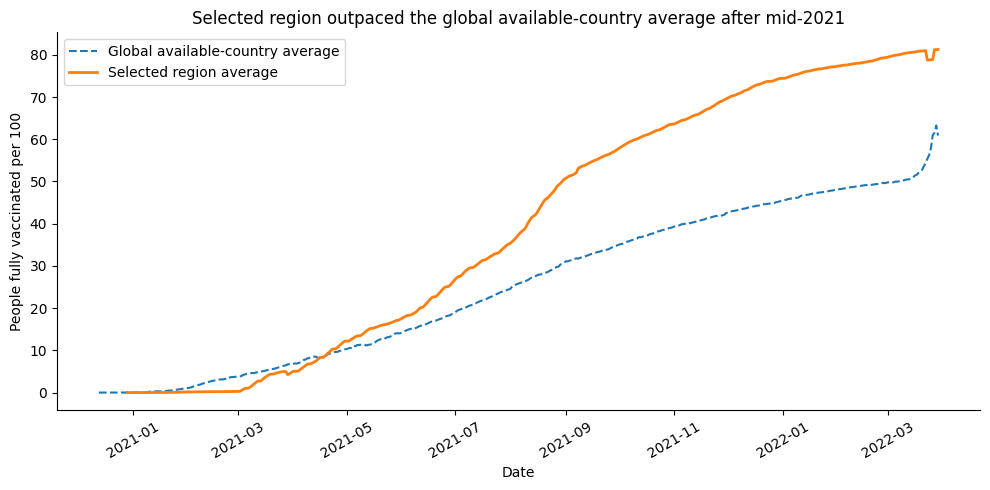

In [26]:
# Chart 1 of 8: Region vs global vaccination benchmark
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    global_average["date"],
    global_average["global_available_country_average"],
    linestyle="--",
    label="Global available-country average"
)

ax.plot(
    regional_average["date"],
    regional_average["selected_region_average"],
    linewidth=2,
    label="Selected region average"
)

ax.set_title("Selected region outpaced the global available-country average after mid-2021")
ax.set_xlabel("Date")
ax.set_ylabel("People fully vaccinated per 100")
ax.legend()
plt.xticks(rotation=30)
remove_chart_clutter(ax)
plt.tight_layout()
plt.show()

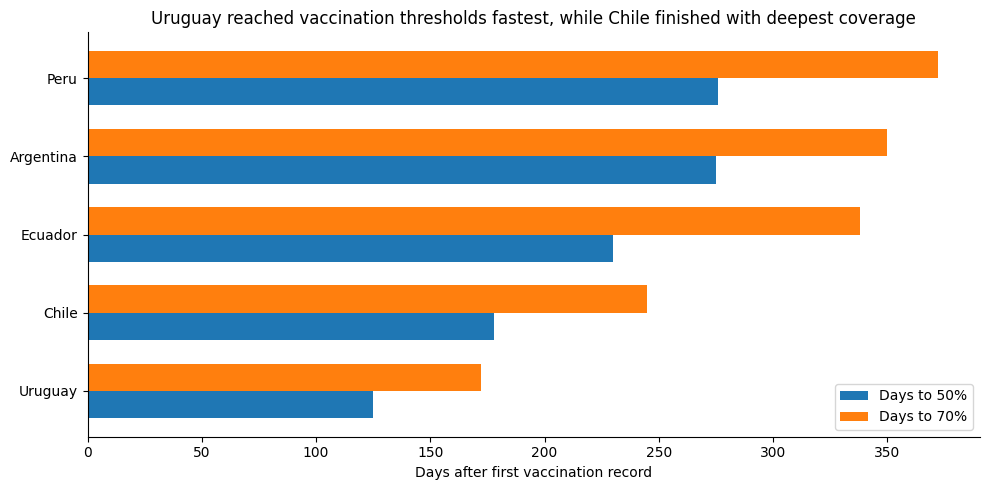

In [27]:
# Chart 2 of 8: Days to vaccination thresholds
threshold_plot = vaccination_metrics.sort_values("days_to_70_full").reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
y = np.arange(len(threshold_plot))
bar_height = 0.35

ax.barh(y - bar_height / 2, threshold_plot["days_to_50_full"], height=bar_height, label="Days to 50%")
ax.barh(y + bar_height / 2, threshold_plot["days_to_70_full"], height=bar_height, label="Days to 70%")

ax.set_yticks(y)
ax.set_yticklabels(threshold_plot["country"])
ax.set_title("Uruguay reached vaccination thresholds fastest, while Chile finished with deepest coverage")
ax.set_xlabel("Days after first vaccination record")
ax.legend()
remove_chart_clutter(ax)
plt.tight_layout()
plt.show()

**2A interpretation:** Chile finished with the deepest vaccination coverage, while Uruguay reached 50% and 70% full vaccination fastest. Vaccination readiness depends on both final coverage and timing.

# 2B. Variant Timing Readiness

## Question

Were countries already vaccinated when major variants became dominant?

Methodology:
- Analyze named variants from the long-format variant table, not only `dominant_variant`.
- Focus on Gamma, Lambda, Delta, and Omicron.
- Use first reliable date above 50% sequences as dominance.
- Require at least 50 total sequences for a reliable dominance event.
- Compare Delta/Omicron dominance timing with vaccination coverage at that date.

Severity limitation:
- Death and recovery data are cumulative, so they are used only as broad severity context, not wave-level causal proof.

In [28]:
MAJOR_VARIANTS = ["gamma", "lambda", "delta", "omicron"]
VARIANT_DISPLAY = {"gamma": "Gamma", "lambda": "Lambda", "delta": "Delta", "omicron": "Omicron"}
MIN_SEQUENCES_FOR_DOMINANCE = 50

variants_2b = variants_region.copy()
variants_2b["variant_lower"] = variants_2b["variant"].astype(str).str.strip().str.lower()

variants_named = variants_2b[variants_2b["variant_lower"].isin(MAJOR_VARIANTS)].copy()
variants_named["variant_display"] = variants_named["variant_lower"].map(VARIANT_DISPLAY)

variant_wave_rows = []

for country in COUNTRIES:
    for variant_lower in MAJOR_VARIANTS:
        sub = variants_named[
            (variants_named["country"] == country)
            & (variants_named["variant_lower"] == variant_lower)
        ].copy()

        observed = sub[(sub["date"].notna()) & (sub["num_sequences_total"] > 0)]
        positive = observed[observed["num_sequences"] > 0]
        reliable = positive[positive["num_sequences_total"] >= MIN_SEQUENCES_FOR_DOMINANCE]
        reliable_dominance = reliable[reliable["perc_sequences"] >= 50]

        variant_wave_rows.append({
            "country": country,
            "variant": VARIANT_DISPLAY[variant_lower],
            "first_observed_date": positive["date"].min() if not positive.empty else pd.NaT,
            "first_50pct_reliable_date": reliable_dominance["date"].min() if not reliable_dominance.empty else pd.NaT,
            "max_percent": positive["perc_sequences"].max() if not positive.empty else np.nan
        })

variant_wave_summary = pd.DataFrame(variant_wave_rows)

def vaccination_at_or_before(country, event_date):
    if pd.isna(event_date):
        return np.nan
    sub = vaccination_2a[
        (vaccination_2a["country"] == country)
        & (vaccination_2a["date"] <= event_date)
    ].sort_values("date")
    if sub.empty:
        return np.nan
    return sub.tail(1).iloc[0]["people_fully_vaccinated_per_hundred"]

variant_dominance_vaccination = variant_wave_summary[
    variant_wave_summary["first_50pct_reliable_date"].notna()
].copy()

variant_dominance_vaccination["fully_vaccinated_at_event"] = (
    variant_dominance_vaccination
    .apply(lambda row: vaccination_at_or_before(row["country"], row["first_50pct_reliable_date"]), axis=1)
)

variant_dominance_vaccination

,country,variant,first_observed_date,first_50pct_reliable_date,max_percent,fully_vaccinated_at_event
0,Argentina,Gamma,2021-01-25,2021-05-17,73.60,4.97
2,Argentina,Delta,2020-11-23,2021-11-01,89.74,58.35
3,Argentina,Omicron,2021-12-13,2021-12-27,85.11,72.41
4,Chile,Gamma,2021-01-11,2021-05-17,70.79,39.44
6,Chile,Delta,2021-01-04,2021-09-20,98.78,73.10
7,Chile,Omicron,2021-11-29,2021-12-27,51.59,85.84
9,Peru,Lambda,2021-01-04,2021-03-08,82.87,0.32
10,Peru,Delta,2021-05-17,2021-09-20,97.63,29.77
14,Ecuador,Delta,2021-06-28,2021-09-06,96.77,49.29
16,Uruguay,Gamma,2021-03-08,2021-03-22,84.21,NaN


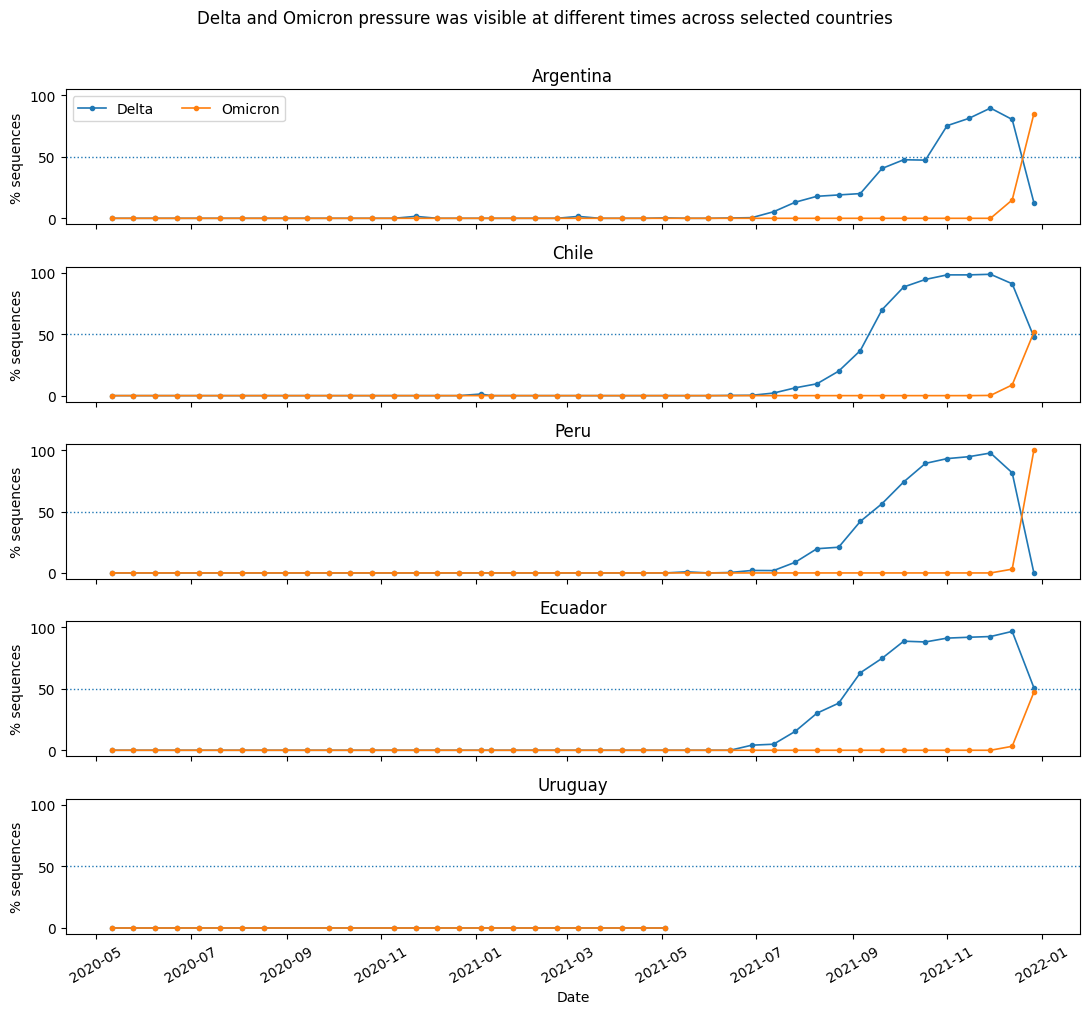

In [29]:
# Chart 3 of 8: Delta and Omicron prevalence over time
# Gamma and Lambda remain in variant_wave_summary as early-wave context.
# This main chart focuses on late variants because they connect most directly to vaccination readiness.

LATE_VARIANTS = ["delta", "omicron"]

fig, axes = plt.subplots(len(COUNTRIES), 1, figsize=(11, 10), sharex=True, sharey=True)

for ax, country in zip(axes, COUNTRIES):
    country_data = variants_named[variants_named["country"] == country]

    for variant_lower in LATE_VARIANTS:
        variant_name = VARIANT_DISPLAY[variant_lower]
        sub = country_data[country_data["variant_display"] == variant_name]
        ax.plot(
            sub["date"],
            sub["perc_sequences"],
            marker="o",
            markersize=3,
            linewidth=1.2,
            label=variant_name
        )

    ax.axhline(50, linestyle=":", linewidth=1)
    ax.set_title(country)
    ax.set_ylabel("% sequences")

axes[-1].set_xlabel("Date")
axes[0].legend(ncol=2)

fig.suptitle(
    "Delta and Omicron pressure was visible at different times across selected countries",
    y=1.01
)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

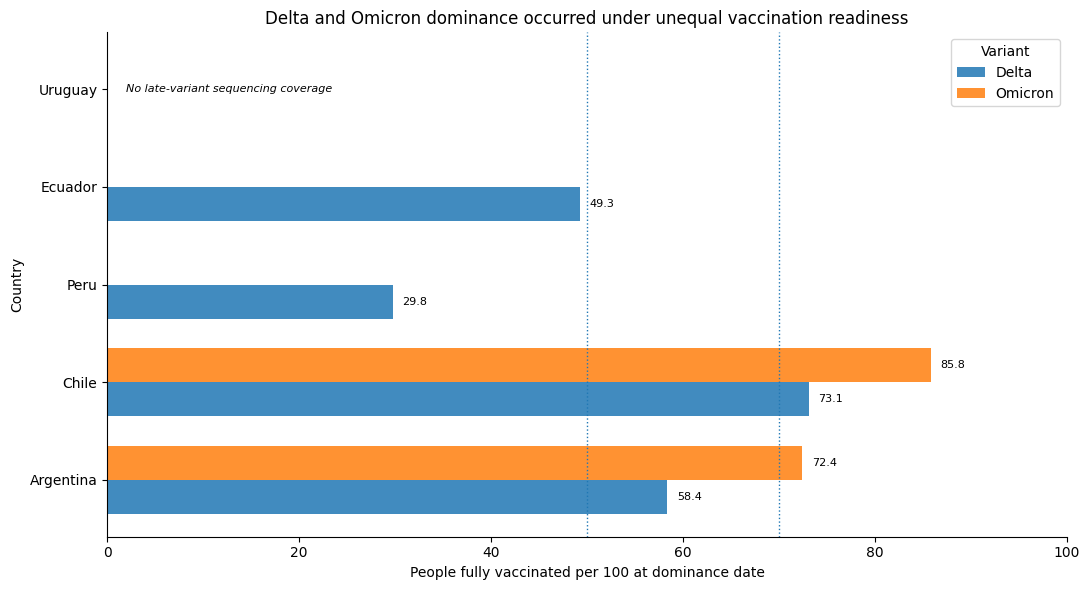

In [30]:
# Chart 4 of 8: Vaccination coverage at Delta/Omicron dominance
# Grouped bars are clearer than sparse scatter points for comparing vaccination readiness at dominance.

late_variant_events = variant_dominance_vaccination[
    variant_dominance_vaccination["variant"].isin(["Delta", "Omicron"])
].copy()

late_coverage = (
    late_variant_events
    .pivot_table(
        index="country",
        columns="variant",
        values="fully_vaccinated_at_event",
        aggfunc="first"
    )
    .reindex(COUNTRIES)
)

for col in ["Delta", "Omicron"]:
    if col not in late_coverage.columns:
        late_coverage[col] = np.nan

late_coverage = late_coverage[["Delta", "Omicron"]]

# Identify countries where late-variant sequencing coverage is not available.
late_variant_visibility_cutoff = pd.Timestamp("2021-08-01")

late_variant_visibility = (
    variants_region
    .groupby("country")
    .agg(last_sequencing_date=("date", "max"))
    .reset_index()
)

visibility_map = late_variant_visibility.set_index("country")["last_sequencing_date"].to_dict()

fig, ax = plt.subplots(figsize=(11, 6))

y = np.arange(len(late_coverage.index))
bar_height = 0.35

for offset, variant_name in [(-bar_height / 2, "Delta"), (bar_height / 2, "Omicron")]:
    values = late_coverage[variant_name]

    ax.barh(
        y + offset,
        values.fillna(0),
        height=bar_height,
        label=variant_name,
        alpha=0.85
    )

    for i, value in enumerate(values):
        if pd.notna(value):
            ax.text(
                value + 1,
                y[i] + offset,
                f"{value:.1f}",
                va="center",
                fontsize=8
            )

# Annotate countries with no late-variant sequencing coverage or no reliable dominance event.
for i, country in enumerate(late_coverage.index):
    if late_coverage.loc[country].isna().all():
        last_seq = visibility_map.get(country, pd.NaT)
        if pd.notna(last_seq) and last_seq < late_variant_visibility_cutoff:
            note = "No late-variant sequencing coverage"
        else:
            note = "No reliable Delta/Omicron dominance"
        ax.text(
            2,
            y[i],
            note,
            va="center",
            fontsize=8,
            style="italic"
        )

ax.axvline(50, linestyle=":", linewidth=1)
ax.axvline(70, linestyle=":", linewidth=1)

ax.set_yticks(y)
ax.set_yticklabels(late_coverage.index)

ax.set_xlim(0, 100)
ax.set_title("Delta and Omicron dominance occurred under unequal vaccination readiness")
ax.set_xlabel("People fully vaccinated per 100 at dominance date")
ax.set_ylabel("Country")
ax.legend(title="Variant")

remove_chart_clutter(ax)
plt.tight_layout()
plt.show()

In [31]:
# Variant timing profile
variant_visibility = (
    variants_region
    .groupby("country")
    .agg(
        sequencing_dates=("date", "nunique"),
        last_sequencing_date=("date", "max")
    )
    .reset_index()
)

variant_timing_rows = []
late_variant_cutoff = pd.Timestamp("2021-08-01")

for country in COUNTRIES:
    visibility_row = variant_visibility[variant_visibility["country"] == country].iloc[0]
    country_late_events = late_variant_events[late_variant_events["country"] == country]

    if visibility_row["last_sequencing_date"] < late_variant_cutoff:
        label = "No late-variant sequencing coverage"
    elif country_late_events.empty:
        label = "No reliable Delta/Omicron dominance captured"
    else:
        lowest_vaccination_at_late_variant = country_late_events["fully_vaccinated_at_event"].min()
        if lowest_vaccination_at_late_variant >= 70:
            label = "Later variants after vaccine maturity"
        elif lowest_vaccination_at_late_variant >= 50:
            label = "Later variants after partial maturity"
        else:
            label = "Later variants before 50% full vaccination"

    variant_timing_rows.append({
        "country": country,
        "variant_timing_readiness_label": label,
        "sequencing_dates": visibility_row["sequencing_dates"],
        "last_sequencing_date": visibility_row["last_sequencing_date"]
    })

variant_timing_profile = pd.DataFrame(variant_timing_rows)

variant_timing_profile.merge(
    country_summary[["country", "death_to_case_ratio", "recovery_ratio"]],
    on="country",
    how="left"
)

,country,variant_timing_readiness_label,sequencing_dates,last_sequencing_date,death_to_case_ratio,recovery_ratio
0,Argentina,Later variants after partial maturity,44,2021-12-27,1.291575,98.708425
1,Chile,Later variants after vaccine maturity,44,2021-12-27,1.161076,98.838924
2,Peru,Later variants before 50% full vaccination,44,2021-12-27,4.880515,95.119485
3,Ecuador,Later variants before 50% full vaccination,44,2021-12-27,3.349915,96.650085
4,Uruguay,No late-variant sequencing coverage,24,2021-05-03,0.734661,99.265339


**2B variant-pressure clarification:** Within the limits of the available data, the strongest variant-pressure events were Gamma in Argentina/Chile, Lambda in Peru, and Delta across Peru/Ecuador/Chile/Argentina. These are treated as pressure events because they reached high sequencing prevalence, not as proven causes of death changes.

First observed dates refer to first positive sequencing observations in this dataset, not necessarily the true first arrival of the variant in the country.

**2B interpretation:** The main late-variant readiness comparison focuses on Delta and Omicron because these variants best test whether vaccination maturity had been reached. Gamma and Lambda are kept as early-wave context in the summary table. Variant pressure did not arrive under equal vaccination readiness: Chile and Argentina had stronger vaccination coverage when late variants became dominant, while Peru and Ecuador faced Delta before 50% full vaccination. Uruguay lacks late-variant sequencing coverage, so late-variant readiness cannot be judged from this dataset.


# 2C. Manufacturer Supply Resilience

## Question

Did countries rely on narrow or diversified vaccine manufacturer portfolios?

Methodology:
- Use the latest cumulative row per `country + vaccine`.
- Do not sum cumulative rows across dates.
- Calculate manufacturer share, top manufacturer share, number of manufacturers, HHI concentration, and effective number of manufacturers.

Interpretation limit:
- Manufacturer mix means supply strategy and dependency, not biological vaccine effectiveness.

In [32]:
manufacturer_2c = manufacturer_region.sort_values(["country", "vaccine", "date"]).copy()

manufacturer_final_mix = (
    manufacturer_2c
    .sort_values("date")
    .groupby(["country", "vaccine"], as_index=False)
    .tail(1)
    .copy()
)

manufacturer_final_mix["country_total_doses"] = (
    manufacturer_final_mix.groupby("country")["total_vaccinations"].transform("sum")
)

manufacturer_final_mix["manufacturer_share"] = (
    manufacturer_final_mix["total_vaccinations"] / manufacturer_final_mix["country_total_doses"]
)

manufacturer_final_mix["manufacturer_share_percent"] = manufacturer_final_mix["manufacturer_share"] * 100

top_manufacturer = (
    manufacturer_final_mix
    .sort_values(["country", "manufacturer_share"], ascending=[True, False])
    .groupby("country")
    .first()
    .reset_index()
    [["country", "vaccine", "manufacturer_share_percent"]]
    .rename(columns={
        "vaccine": "top_manufacturer",
        "manufacturer_share_percent": "top_manufacturer_share_percent"
    })
)

manufacturer_profile = (
    manufacturer_final_mix
    .groupby("country")
    .agg(
        number_of_manufacturers=("vaccine", "nunique"),
        hhi=("manufacturer_share", lambda x: (x ** 2).sum()),
        final_manufacturer_total_doses=("total_vaccinations", "sum")
    )
    .reset_index()
    .merge(top_manufacturer, on="country", how="left")
)

manufacturer_profile["effective_number_of_manufacturers"] = 1 / manufacturer_profile["hhi"]

def manufacturer_label(row):
    if row["top_manufacturer_share_percent"] >= 70 or row["hhi"] >= 0.50:
        return "Concentrated supply profile"
    elif row["top_manufacturer_share_percent"] >= 50 or row["hhi"] >= 0.30:
        return "Moderately diversified supply profile"
    else:
        return "Diversified supply profile"

manufacturer_profile["manufacturer_supply_resilience_label"] = manufacturer_profile.apply(manufacturer_label, axis=1)

manufacturer_interpretation = manufacturer_profile[[
    "country",
    "top_manufacturer",
    "top_manufacturer_share_percent",
    "number_of_manufacturers",
    "hhi",
    "effective_number_of_manufacturers",
    "manufacturer_supply_resilience_label"
]].copy()

manufacturer_interpretation

,country,top_manufacturer,top_manufacturer_share_percent,number_of_manufacturers,hhi,effective_number_of_manufacturers,manufacturer_supply_resilience_label
0,Argentina,Sinopharm/Beijing,29.348428,6,0.231032,4.328411,Diversified supply profile
1,Chile,Sinovac,73.913273,4,0.599018,1.669400,Concentrated supply profile
2,Ecuador,Sinovac,52.865456,4,0.389599,2.566741,Moderately diversified supply profile
3,Peru,Pfizer/BioNTech,60.789070,3,0.472254,2.117504,Moderately diversified supply profile
4,Uruguay,Sinovac,55.851889,3,0.493559,2.026098,Moderately diversified supply profile


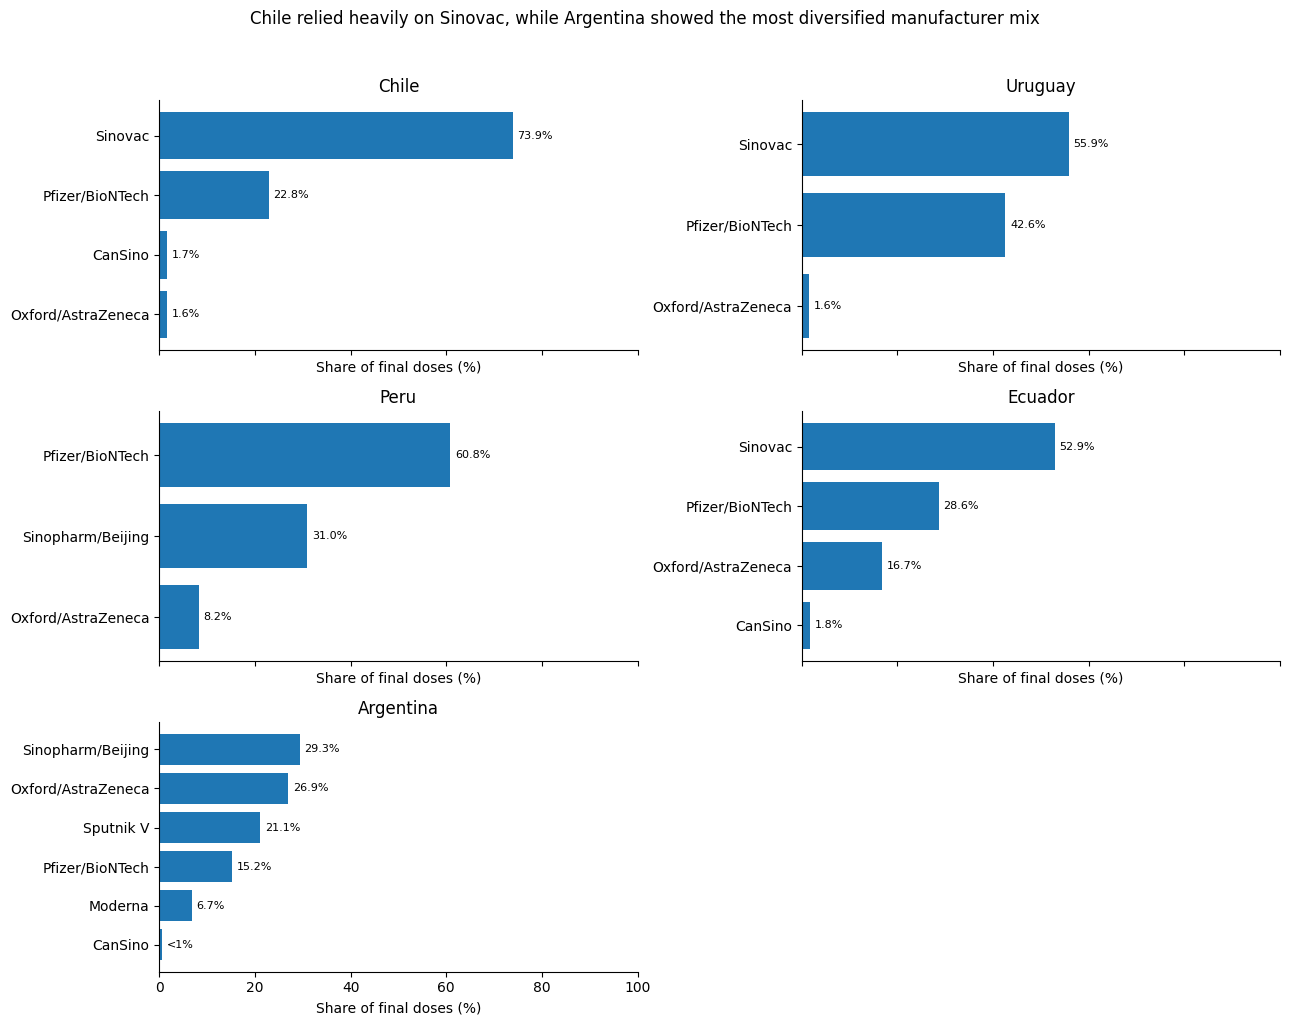

In [33]:
# Chart 5 of 8: Manufacturer mix by country using small-multiple ranked bar charts
# One mini horizontal bar chart per country makes manufacturer dependency easier to read than a dense heatmap.

country_order_by_concentration = (
    manufacturer_profile
    .sort_values("hhi", ascending=False)["country"]
    .tolist()
)

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(13, 10),
    sharex=True
)

axes = axes.flatten()

for ax, country in zip(axes, country_order_by_concentration):
    country_mix = (
        manufacturer_final_mix[manufacturer_final_mix["country"] == country]
        .sort_values("manufacturer_share_percent", ascending=True)
        .copy()
    )

    ax.barh(
        country_mix["vaccine"],
        country_mix["manufacturer_share_percent"]
    )

    ax.set_title(country)
    ax.set_xlim(0, 100)
    ax.set_xlabel("Share of final doses (%)")

    for i, value in enumerate(country_mix["manufacturer_share_percent"]):
        if value < 1:
            label = "<1%"
        else:
            label = f"{value:.1f}%"

        ax.text(
            value + 1,
            i,
            label,
            va="center",
            fontsize=8
        )

    remove_chart_clutter(ax)

# Hide the unused sixth panel
for ax in axes[len(country_order_by_concentration):]:
    ax.axis("off")

fig.suptitle(
    "Chile relied heavily on Sinovac, while Argentina showed the most diversified manufacturer mix",
    y=1.02
)

plt.tight_layout()
plt.show()

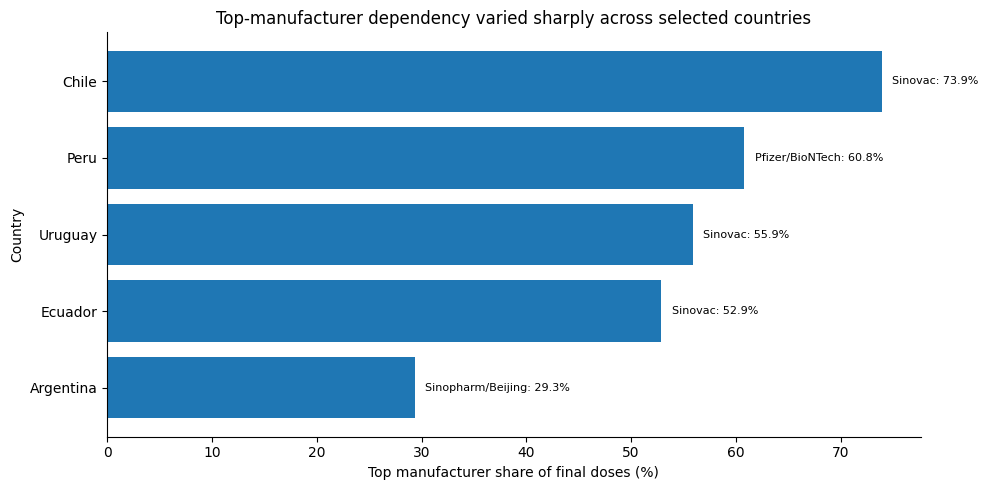

In [34]:
# Chart 6 of 8: Top manufacturer dependency
dependency_plot = manufacturer_profile.sort_values("top_manufacturer_share_percent")

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(dependency_plot["country"], dependency_plot["top_manufacturer_share_percent"])

for i, row in dependency_plot.reset_index(drop=True).iterrows():
    ax.text(
        row["top_manufacturer_share_percent"] + 1,
        i,
        f'{row["top_manufacturer"]}: {row["top_manufacturer_share_percent"]:.1f}%',
        va="center",
        fontsize=8
    )

ax.set_title("Top-manufacturer dependency varied sharply across selected countries")
ax.set_xlabel("Top manufacturer share of final doses (%)")
ax.set_ylabel("Country")
remove_chart_clutter(ax)
plt.tight_layout()
plt.show()

**2C potential reasons and limits:** Possible reasons for manufacturer dominance include earlier availability, procurement agreements, delivery reliability, storage and logistics constraints, and national rollout strategy. These are treated as plausible explanations, not proven causes, because this dataset does not include procurement contracts, delivery schedules, pricing, public acceptance, or policy decisions.

**2C interpretation:** The small-multiple bar charts make the manufacturer story easier to read by showing each country’s portfolio separately. Chile relied heavily on Sinovac, Peru relied mainly on Pfizer/BioNTech, and Argentina showed the most diversified manufacturer mix. Concentrated supply does not mean failure, and diversified supply does not automatically mean better outcomes. It shows supply strategy and potential vulnerability.


# 2D. Testing Visibility

## Question

How visible and comparable was the pandemic in official testing data?

Methodology:
- Compare final cumulative testing per thousand.
- Compare median positivity and tests per case.
- Track missingness in key testing fields.
- Compare testing indicators with cumulative outcomes cautiously.

Scatterplots are avoided because there are only five countries, testing definitions differ, and outcome data is cumulative.

In [35]:
testing_2d = testing_region.sort_values(["country", "date"]).copy()

def last_non_null(series):
    non_null = series.dropna()
    if non_null.empty:
        return np.nan
    return non_null.iloc[-1]

testing_rows = []

for country in COUNTRIES:
    sub = testing_2d[testing_2d["country"] == country].sort_values("date")

    testing_rows.append({
        "country": country,
        "testing_method": ", ".join(sorted(sub["testing_method"].dropna().unique())),
        "testing_observation_dates": sub["date"].nunique(),
        "final_cumulative_tests_per_thousand": last_non_null(sub["Cumulative total per thousand"]),
        "median_positive_rate_percent": sub["Short-term positive rate"].median(skipna=True) * 100,
        "median_tests_per_case": sub["Short-term tests per case"].median(skipna=True),
        "positive_rate_missing_pct": sub["Short-term positive rate"].isna().mean() * 100,
        "tests_per_case_missing_pct": sub["Short-term tests per case"].isna().mean() * 100
    })

testing_profile = pd.DataFrame(testing_rows)

testing_profile["average_testing_missing_pct"] = (
    testing_profile[["positive_rate_missing_pct", "tests_per_case_missing_pct"]]
    .mean(axis=1)
)

testing_profile["testing_intensity_score"] = normalize_high_good(testing_profile["final_cumulative_tests_per_thousand"])
testing_profile["positive_rate_score"] = normalize_low_good(testing_profile["median_positive_rate_percent"])
testing_profile["tests_per_case_score"] = normalize_high_good(testing_profile["median_tests_per_case"])
testing_profile["completeness_score"] = normalize_low_good(testing_profile["average_testing_missing_pct"])

testing_profile["testing_visibility_index"] = (
    0.35 * testing_profile["testing_intensity_score"]
    + 0.25 * testing_profile["positive_rate_score"]
    + 0.25 * testing_profile["tests_per_case_score"]
    + 0.15 * testing_profile["completeness_score"]
)

def testing_label(score):
    if pd.isna(score):
        return "Insufficient data"
    if score >= 0.70:
        return "Higher testing visibility profile"
    elif score >= 0.40:
        return "Middle testing visibility profile"
    else:
        return "Lower testing visibility profile within selected countries"

testing_profile["testing_visibility_label"] = testing_profile["testing_visibility_index"].apply(testing_label)

testing_interpretation = testing_profile[[
    "country",
    "testing_method",
    "final_cumulative_tests_per_thousand",
    "median_positive_rate_percent",
    "median_tests_per_case",
    "average_testing_missing_pct",
    "testing_visibility_label"
]].copy()

testing_interpretation

,country,testing_method,final_cumulative_tests_per_thousand,median_positive_rate_percent,median_tests_per_case,average_testing_missing_pct,testing_visibility_label
0,Argentina,tests performed,579.560,18.500,5.4,3.267045,Lower testing visibility profile within select...
1,Chile,tests performed,1349.738,7.045,14.2,1.120000,Higher testing visibility profile
2,Peru,tests performed,178.690,10.800,9.1,4.680535,Lower testing visibility profile within select...
3,Ecuador,people tested,108.481,25.685,3.9,28.650794,Lower testing visibility profile within select...
4,Uruguay,people tested,1199.691,2.070,48.3,1.114650,Higher testing visibility profile


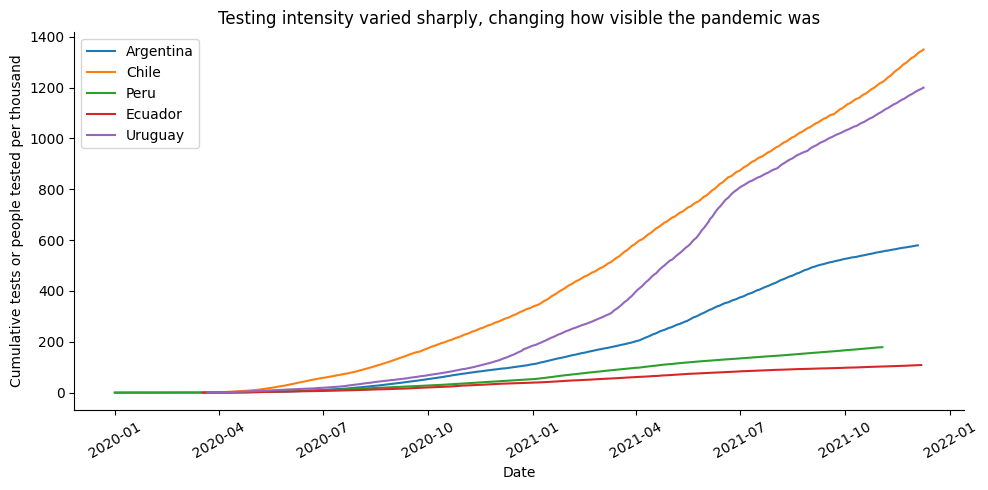

In [36]:
# Chart 7 of 8: Testing intensity over time
testing_trend = testing_2d.copy()
testing_trend["cumulative_testing_ffill"] = (
    testing_trend
    .groupby("country")["Cumulative total per thousand"]
    .ffill()
)

fig, ax = plt.subplots(figsize=(10, 5))

for country in COUNTRIES:
    sub = testing_trend[testing_trend["country"] == country]
    ax.plot(sub["date"], sub["cumulative_testing_ffill"], label=country)

ax.set_title("Testing intensity varied sharply, changing how visible the pandemic was")
ax.set_xlabel("Date")
ax.set_ylabel("Cumulative tests or people tested per thousand")
ax.legend()
plt.xticks(rotation=30)
remove_chart_clutter(ax)
plt.tight_layout()
plt.show()

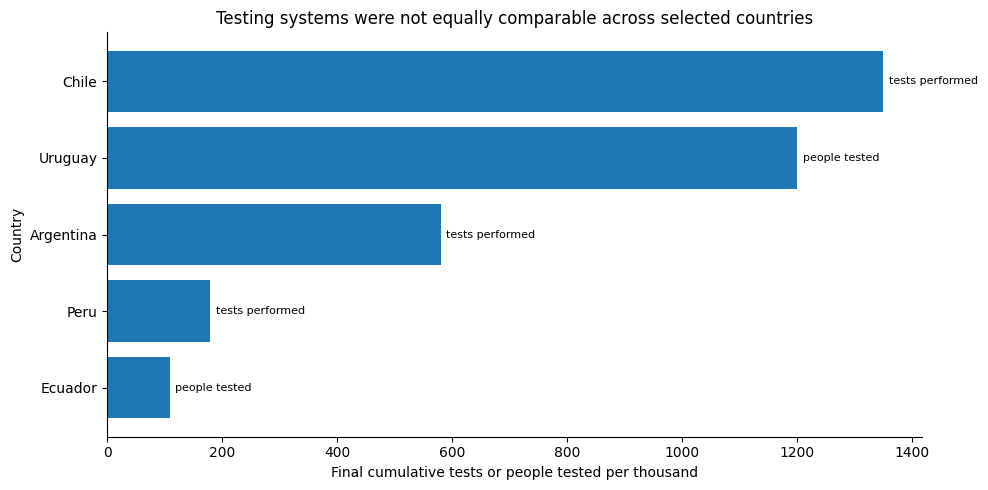

In [37]:
# Chart 8 of 8: Testing visibility comparison
testing_visibility_plot = testing_profile.sort_values("final_cumulative_tests_per_thousand")

fig, ax = plt.subplots(figsize=(10, 5))

ax.barh(
    testing_visibility_plot["country"],
    testing_visibility_plot["final_cumulative_tests_per_thousand"]
)

for i, row in testing_visibility_plot.reset_index(drop=True).iterrows():
    ax.text(
        row["final_cumulative_tests_per_thousand"] + 10,
        i,
        row["testing_method"],
        va="center",
        fontsize=8
    )

ax.set_title("Testing systems were not equally comparable across selected countries")
ax.set_xlabel("Final cumulative tests or people tested per thousand")
ax.set_ylabel("Country")
remove_chart_clutter(ax)
plt.tight_layout()
plt.show()

## 2D Testing Evolution Summary

This table summarizes how positivity and tests-per-case changed from the earlier to later half of each country’s testing record. It complements the testing-volume trend chart without adding another visualization, keeping the main chart count at eight.

In [38]:
testing_evolution_rows = []

for country in COUNTRIES:
    sub = testing_2d[testing_2d["country"] == country].sort_values("date").copy()
    midpoint = sub["date"].median()

    early = sub[sub["date"] <= midpoint]
    late = sub[sub["date"] > midpoint]

    testing_evolution_rows.append({
        "country": country,
        "early_median_positive_rate_percent": early["Short-term positive rate"].median(skipna=True) * 100,
        "late_median_positive_rate_percent": late["Short-term positive rate"].median(skipna=True) * 100,
        "early_median_tests_per_case": early["Short-term tests per case"].median(skipna=True),
        "late_median_tests_per_case": late["Short-term tests per case"].median(skipna=True)
    })

testing_evolution_summary = pd.DataFrame(testing_evolution_rows)
testing_evolution_summary

,country,early_median_positive_rate_percent,late_median_positive_rate_percent,early_median_tests_per_case,late_median_tests_per_case
0,Argentina,24.00,14.600,4.20,6.80
1,Chile,7.44,5.305,13.45,18.85
2,Peru,18.30,8.450,5.10,11.85
3,Ecuador,23.49,26.640,4.30,3.80
4,Uruguay,0.95,8.220,105.40,12.15


Raw cumulative case counts are shown only as broad outcome context because they are not population-normalized and are affected by testing visibility. Therefore, the relationship between testing intensity and reported cases is interpreted through visibility indicators such as positivity rate and tests per case, not through raw case totals alone.

In [39]:
# Testing and outcome context table
testing_outcome_context = testing_profile.merge(country_summary, on="country", how="left")

testing_outcome_context[[
    "country",
    "testing_method",
    "final_cumulative_tests_per_thousand",
    "median_positive_rate_percent",
    "median_tests_per_case",
    "Cases",
    "death_to_case_ratio",
    "testing_visibility_label"
]]

,country,testing_method,final_cumulative_tests_per_thousand,median_positive_rate_percent,median_tests_per_case,Cases,death_to_case_ratio,testing_visibility_label
0,Argentina,tests performed,579.560,18.500,5.4,10131586.0,1.291575,Lower testing visibility profile within select...
1,Chile,tests performed,1349.738,7.045,14.2,5399992.0,1.161076,Higher testing visibility profile
2,Peru,tests performed,178.690,10.800,9.1,4524748.0,4.880515,Lower testing visibility profile within select...
3,Ecuador,people tested,108.481,25.685,3.9,1076087.0,3.349915,Lower testing visibility profile within select...
4,Uruguay,people tested,1199.691,2.070,48.3,1037893.0,0.734661,Higher testing visibility profile


**2D interpretation:** Reported cases are not pure disease counts; they are outputs of a testing system. Low testing intensity, high positivity, or low tests per case can make official case counts less comparable across countries.

# Integrated Readiness Profile

This final table connects the four Part 2 dimensions. It is a profile, not a winner ranking.

In [40]:
readiness_profile = (
    pd.DataFrame({"country": COUNTRIES})
    .merge(vaccination_interpretation[["country", "vaccination_readiness_label"]], on="country", how="left")
    .merge(variant_timing_profile[["country", "variant_timing_readiness_label"]], on="country", how="left")
    .merge(manufacturer_interpretation[[
        "country",
        "manufacturer_supply_resilience_label",
        "top_manufacturer",
        "top_manufacturer_share_percent"
    ]], on="country", how="left")
    .merge(testing_interpretation[["country", "testing_visibility_label"]], on="country", how="left")
)

def summarize_profile(row):
    return (
        f"Vaccination: {row['vaccination_readiness_label']}; "
        f"Variant timing: {row['variant_timing_readiness_label']}; "
        f"Manufacturer: {row['manufacturer_supply_resilience_label']} "
        f"({row['top_manufacturer']}, {row['top_manufacturer_share_percent']:.1f}%); "
        f"Testing: {row['testing_visibility_label']}."
    )

readiness_profile["overall_profile"] = readiness_profile.apply(summarize_profile, axis=1)

required_profile_columns = [
    "vaccination_readiness_label",
    "variant_timing_readiness_label",
    "manufacturer_supply_resilience_label",
    "testing_visibility_label"
]

assert len(readiness_profile) == len(COUNTRIES)
assert readiness_profile[required_profile_columns].notna().all().all()

readiness_profile

,country,vaccination_readiness_label,variant_timing_readiness_label,manufacturer_supply_resilience_label,top_manufacturer,top_manufacturer_share_percent,testing_visibility_label,overall_profile
0,Argentina,Later rollout profile within selected countries,Later variants after partial maturity,Diversified supply profile,Sinopharm/Beijing,29.348428,Lower testing visibility profile within select...,Vaccination: Later rollout profile within sele...
1,Chile,Earlier/deeper rollout profile,Later variants after vaccine maturity,Concentrated supply profile,Sinovac,73.913273,Higher testing visibility profile,Vaccination: Earlier/deeper rollout profile; V...
2,Peru,Later rollout profile within selected countries,Later variants before 50% full vaccination,Moderately diversified supply profile,Pfizer/BioNTech,60.789070,Lower testing visibility profile within select...,Vaccination: Later rollout profile within sele...
3,Ecuador,Later rollout profile within selected countries,Later variants before 50% full vaccination,Moderately diversified supply profile,Sinovac,52.865456,Lower testing visibility profile within select...,Vaccination: Later rollout profile within sele...
4,Uruguay,Earlier/deeper rollout profile,No late-variant sequencing coverage,Moderately diversified supply profile,Sinovac,55.851889,Higher testing visibility profile,Vaccination: Earlier/deeper rollout profile; V...


**Integrated interpretation:** The selected countries show different readiness profiles, not one simple winner. Vaccination coverage, variant timing, manufacturer supply concentration, and testing visibility must be interpreted together.